<img src="../assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Hypothesis testing in action

---

### About
An introduction to hypothesis testing in action.

### Learning Objectives
- Define the key steps and terms in hypothesis testing.

### Notebook Guide
- Scenario
- Exploring the results
- Now You Try
- Conclusions and Takeaways

# Scenario

You’re an analyst for BIG Sodas, a producer of soft drinks.

They want to bring out a sugar-free version of their most popular lemonade drink, BIG Lemon.

They have two formulas they want to test: BIG Lemon Zero and Diet BIG Lemon.

They want you to help design an experiment to decide which of the two versions to produce.

The basic idea of the experiment is to do blind taste tests to see which flavour people prefer.

# Exploring the results

Let's open and explore the results of one of our blind taste tests.

In [2]:
# pip install scipy
# pip install seaborn

In [3]:
from scipy import stats
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

We have a data set of the two types of soda and the associated taste test rating.

Let's see the distribution of both the sodas and the ratings.

In [4]:
# df = pd.read_csv("../ this goes one step back, if the csv is placed in another folder")
soda_df = pd.read_csv("../data/sodas.csv")

In [5]:
soda_df['soda'].value_counts()

soda
diet_big_lemon    200
big_lemon_zero    200
Name: count, dtype: int64

<Axes: xlabel='rating', ylabel='Count'>

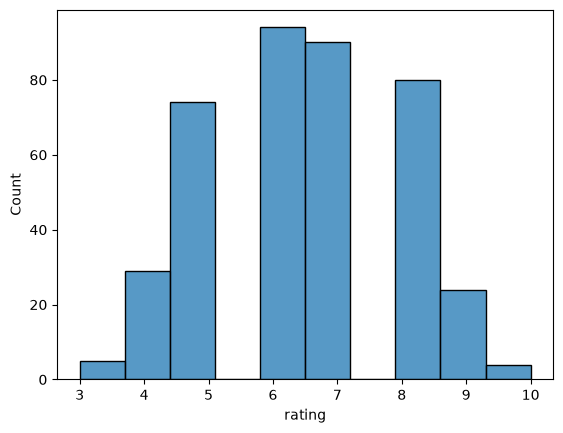

In [6]:
sns.histplot(data=soda_df,
             x="rating",
             )

<Axes: xlabel='rating', ylabel='count'>

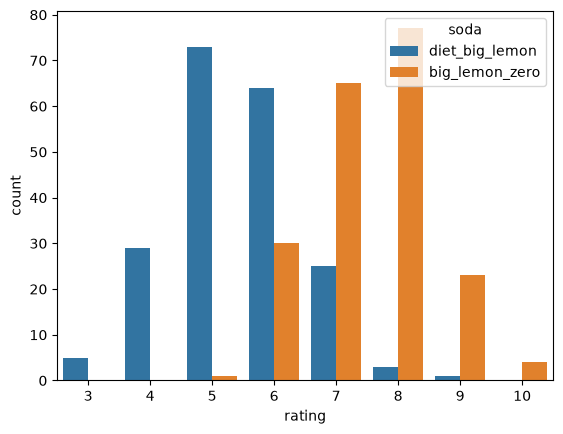

In [7]:
sns.countplot(data=soda_df,
              x='rating',
              hue= "soda")

What we're really interested in is the distribution of ratings *for each soda*.

In [19]:
diet_rating = soda_df[soda_df['soda'] == 'diet_big_lemon']['rating']

zero_rating = soda_df[soda_df['soda'] == 'big_lemon_zero']['rating']

In [20]:
t_stat, p_value = stats.ttest_ind(diet_rating, zero_rating)
p_value

np.float64(9.104493313709996e-65)

This tells us the "peak" of the distributions is different, with Diet BIG Lemon's average seemingly lower.

Let's verify this.

The average rating for Diet BIG Lemon does indeed seem lower.

Now it's time to test this statistically.

First of all, what are our hypotheses?

The null hypothesis is that **there is no difference** between the sodas.

$$
H_0: \mu_1 = \mu_2
$$

The alternate hypothesis is that **there *is* a difference** between the sodas.

$$
H_A: \mu_1 \ne \mu_2
$$

Now we need a statistical test for this scenario.

We'll use a two-sample t-test, which specifically tests **whether there is a significant difference between two sample means**.

In this case, it helps us answer: **do the ratings of these two sodas differ significantly?**

In [8]:
# first, split the samples


# run a t-test to compare groups


To interpret the results, we use the p-value, which tells us **how likely we are to see this data assuming our null hypothesis is true**.

That is: how likely are we to see these ratings if the sodas are equally good?

If the p-value is low enough, we can **reject the null hypothesis** and say that the two sodas are not equal.

That is a tiny p-value, less that the typical threshold of 0.05.

This means **we reject the null hypothesis** and say that there **is** a difference between the sodas and that this difference is statistically significant.

# Now You Try!

We received some more test results, which we want to evaluate.

1. Read in `sodas_2.csv` as a `pandas DataFrame`.

In [21]:
df = pd.read_csv("../data/sodas_2.csv")

2. What is the distribution of sodas?

In [24]:
df.value_counts('soda')

soda
diet_big_lemon    200
big_lemon_zero    200
Name: count, dtype: int64

3. What is the distribution of ratings? Calculate this for the entire dataset, and also for each soda separately.

<Axes: xlabel='rating', ylabel='Count'>

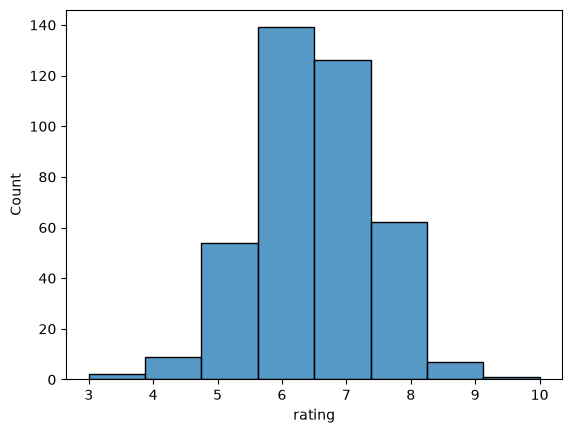

In [27]:
sns.histplot(data= df,
             x= 'rating',
             bins= 8)

<Axes: xlabel='rating', ylabel='count'>

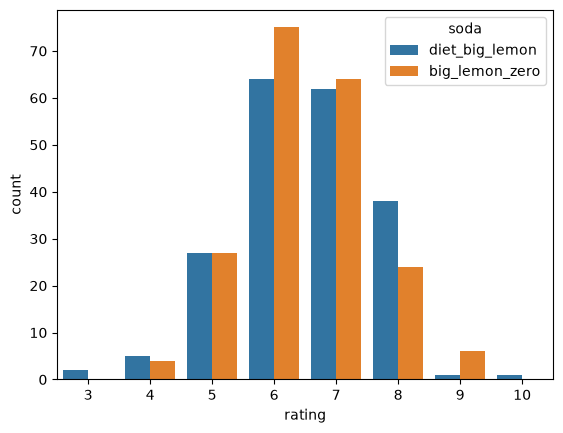

In [26]:
sns.countplot(data= df,
              x= 'rating',
              hue='soda')

Looks like the mean ratings for each soda are very close.

In [30]:
df.groupby('soda').mean()

,rating
soda,
big_lemon_zero,6.475
diet_big_lemon,6.510


4. Run a two-sample t-test to see whether the sodas have similar ratings.

In [32]:
# first, split the samples
diet_rating_2 = df[df['soda'] == 'diet_big_lemon']['rating']

zero_rating_2 = df[df['soda'] == 'big_lemon_zero']['rating']

# run a t-test to compare groups
t_test, p_value = stats.ttest_ind(diet_rating_2, zero_rating_2)

In [33]:
p_value

np.float64(0.7459538558547595)

The p-value is very high, around 0.75.

This means these results are very likely if the two sodas are similar.

We therefore **fail to reject the null hypothesis**.

# Conclusions and Takeaways

- Hypothesis tests require an experiment, data, and a statistical test
- If the p-value is below a certain threshold, usually 0.05, we *reject* the null hypothesis
- If the p-value is above this threshold, we *fail to reject* the null hypothesis